<a href="https://colab.research.google.com/github/ajaykhokhar24/cloud-computing/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter your roll number: 10

Sales Data:
     Electronics  Clothing  Home & Kitchen  Sports
Jan         2289      4197            1527    2344
Feb         4441      4195            2180    3009
Mar         1733      2520            2949    4953
Apr         3042      2032            2097    3304
May         3538      1040            3550    4492
Jun         3419      2552            1356    1239
Jul         3443      3102            4416    4435
Aug         4194      1574            4617    2224
Sep         4940      1974            2713    4763
Oct         4126      1077            4525    1013
Nov         3803      1409            2406    1653
Dec         4932      2366            4870    3718

First 5 Rows:
     Electronics  Clothing  Home & Kitchen  Sports
Jan         2289      4197            1527    2344
Feb         4441      4195            2180    3009
Mar         1733      2520            2949    4953
Apr         3042      2032            2097    3304
May         3538      1040 

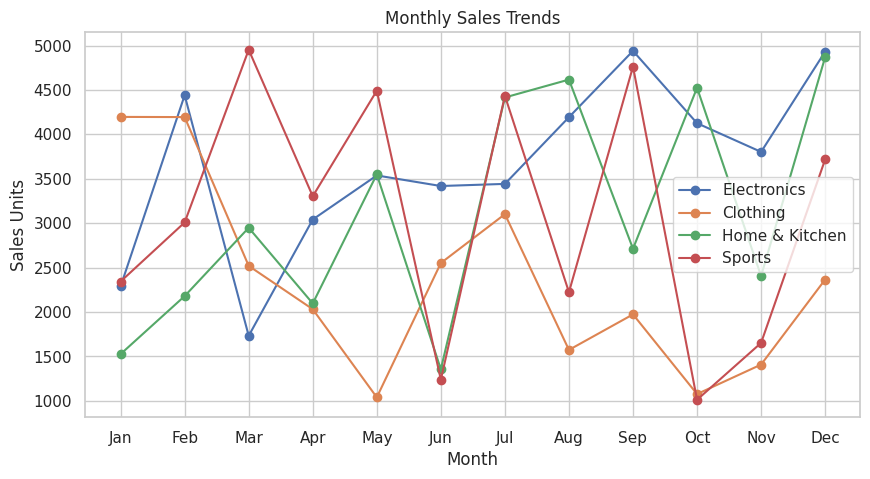

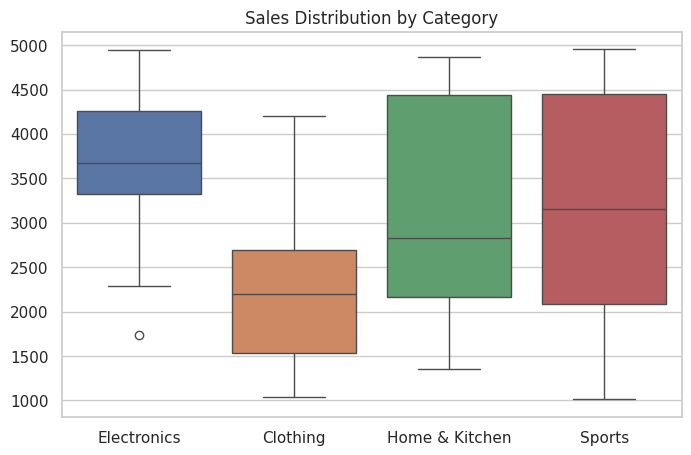


Q2 Array:
[[ 1 -2  3]
 [-4  5 -6]]

Absolute Value:
[[1 2 3]
 [4 5 6]]

Percentiles (Flattened): [-3.5 -0.5  2.5]
Percentiles (Column-wise): [[-2.75 -0.25 -3.75]
 [-1.5   1.5  -1.5 ]
 [-0.25  3.25  0.75]]
Percentiles (Row-wise): [[-0.5 -5. ]
 [ 1.  -4. ]
 [ 2.   0.5]]

Flattened Stats: -0.5 -0.5 3.8622100754188224
Column-wise Stats: [-1.5  1.5 -1.5] [-1.5  1.5 -1.5] [2.5 3.5 4.5]
Row-wise Stats: [ 0.66666667 -1.66666667] [ 1. -4.] [2.05480467 4.78423336]

Q3 Array: [-1.8 -1.6 -0.5  0.5  1.6  1.8  3. ]
Floor: [-2. -2. -1.  0.  1.  1.  3.]
Ceiling: [-1. -1. -0.  1.  2.  2.  3.]
Truncated: [-1. -1. -0.  0.  1.  1.  3.]
Rounded: [-2. -2. -0.  0.  2.  2.  3.]

Q4 Swapped List: [10, 40, 30, 20, 50]

Q5 Original Set: {50, 20, 40, 10, 30}
Swapped Set: {40, 10, 50, 20, 30}


In [1]:
# =====================================================
# Lab Assignment 3 – PCS221 Cloud Computing
# Name: Ajay khokhar
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# =====================================================
# PART I: Randomized Sales Data Generation (NumPy)
# =====================================================

# 1. Initialize Random Seed using Roll Number
ROLL_NUMBER = int(input("Enter your roll number: "))
np.random.seed(ROLL_NUMBER)

# 2. Generate Sales Data (12 months x 4 categories)
months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]
categories = ["Electronics", "Clothing", "Home & Kitchen", "Sports"]

sales_data = np.random.randint(1000, 5001, size=(12, 4))

# 3. Convert to Pandas DataFrame
df = pd.DataFrame(sales_data, index=months, columns=categories)

print("\nSales Data:")
print(df)

# =====================================================
# PART II: Data Manipulation and Analysis (Pandas)
# =====================================================

# 1. First 5 rows & summary statistics
print("\nFirst 5 Rows:")
print(df.head())

print("\nSummary Statistics:")
print(df.describe())

# 2. Total sales per category & per month
total_sales_category = df.sum(axis=0)
total_sales_month = df.sum(axis=1)

print("\nTotal Sales per Category:")
print(total_sales_category)

print("\nTotal Sales per Month:")
print(total_sales_month)

# 3. Average sales growth between consecutive months
avg_growth = df.diff().mean()
print("\nAverage Monthly Growth per Category:")
print(avg_growth)

# 4. Add Total Sales & Growth Rate columns
df["Total Sales"] = df.sum(axis=1)
df["Growth Rate (%)"] = df["Total Sales"].pct_change() * 100

print("\nDataFrame after adding Total Sales & Growth Rate:")
print(df)

# 5. Apply discount based on roll number
df_discounted = df.copy()

if ROLL_NUMBER % 2 == 0:
    df_discounted["Electronics"] *= 0.90   # 10% discount
    print("\nEven Roll Number → 10% discount applied on Electronics")
else:
    df_discounted["Clothing"] *= 0.85      # 15% discount
    print("\nOdd Roll Number → 15% discount applied on Clothing")

print(df_discounted)

# =====================================================
# PART III: Visualizations
# =====================================================

# 1. Monthly sales trends (Line Plot)
plt.figure(figsize=(10,5))
for col in categories:
    plt.plot(df.index, df[col], marker='o', label=col)

plt.title("Monthly Sales Trends")
plt.xlabel("Month")
plt.ylabel("Sales Units")
plt.legend()
plt.show()

# 2. Box Plot – Sales Distribution
plt.figure(figsize=(8,5))
sns.boxplot(data=df[categories])
plt.title("Sales Distribution by Category")
plt.show()

# =====================================================
# Q2
# =====================================================

array = np.array([[1, -2, 3],
                  [-4, 5, -6]])

print("\nQ2 Array:")
print(array)

# i. Absolute value
print("\nAbsolute Value:")
print(np.abs(array))

# ii. Percentiles
flat = array.flatten()
print("\nPercentiles (Flattened):", np.percentile(flat, [25, 50, 75]))
print("Percentiles (Column-wise):", np.percentile(array, [25, 50, 75], axis=0))
print("Percentiles (Row-wise):", np.percentile(array, [25, 50, 75], axis=1))

# iii. Mean, Median, Standard Deviation
print("\nFlattened Stats:",
      np.mean(flat), np.median(flat), np.std(flat))

print("Column-wise Stats:",
      np.mean(array, axis=0),
      np.median(array, axis=0),
      np.std(array, axis=0))

print("Row-wise Stats:",
      np.mean(array, axis=1),
      np.median(array, axis=1),
      np.std(array, axis=1))

# =====================================================
# Q3
# =====================================================

a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

print("\nQ3 Array:", a)
print("Floor:", np.floor(a))
print("Ceiling:", np.ceil(a))
print("Truncated:", np.trunc(a))
print("Rounded:", np.round(a))

# =====================================================
# Q4: Swap two elements in a list (using temp variable)
# =====================================================

lst = [10, 20, 30, 40, 50]
i, j = 1, 3

temp = lst[i]
lst[i] = lst[j]
lst[j] = temp

print("\nQ4 Swapped List:", lst)

# =====================================================
# Q5: Swap elements in a set (via list conversion)
# =====================================================

s = {10, 20, 30, 40, 50}
lst_set = list(s)

i, j = 1, 3
temp = lst_set[i]
lst_set[i] = lst_set[j]
lst_set[j] = temp

s_swapped = set(lst_set)

print("\nQ5 Original Set:", s)
print("Swapped Set:", s_swapped)